<a href="https://www.kaggle.com/code/lalit7881/global-food-prices-database-2026-eda?scriptVersionId=323155956" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2018.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2015.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2016.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2020.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2019.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2023.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2025.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2026.csv
/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2024.csv
/kaggle/input/datasets/abhishekgupta56447/glob

## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abhishekgupta56447/global-food-prices-database-wfp/wfp_food_prices_global_2026.csv")

In [3]:
df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,aggregate,Retail,AFN,77.00,1.16
1,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,aggregate,Retail,AFN,127.93,1.93
2,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,aggregate,Retail,AFN,48.70,0.73
3,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,aggregate,Retail,AFN,26.74,0.40
4,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,aggregate,Retail,AFN,31.26,0.47


In [4]:
df.tail()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
85284,ZMB,2026-01-15,Luapula,Mansa,Mansa,389,-11.20,28.88,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,12.0,0.60
85285,ZMB,2026-01-15,Luapula,Milengi,Milenge,1449,-11.96,29.49,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,11.0,0.55
85286,ZMB,2026-01-15,Lusaka,Luangwa,Luangwa Zaro Market,383,-15.62,30.41,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.0,0.50
85287,ZMB,2026-01-15,Muchiga,Mpika,Mpika,397,-11.84,31.45,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.0,0.50
85288,ZMB,2026-01-15,Muchiga,Nakonde,Nakonde,1454,-9.33,32.77,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,15.0,0.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85289 entries, 0 to 85288
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   countryiso3   85289 non-null  object 
 1   date          85289 non-null  object 
 2   admin1        85260 non-null  object 
 3   admin2        85260 non-null  object 
 4   market        85289 non-null  object 
 5   market_id     85289 non-null  int64  
 6   latitude      85260 non-null  float64
 7   longitude     85260 non-null  float64
 8   category      85289 non-null  object 
 9   commodity     85289 non-null  object 
 10  commodity_id  85289 non-null  int64  
 11  unit          85289 non-null  object 
 12  priceflag     85289 non-null  object 
 13  pricetype     85289 non-null  object 
 14  currency      85289 non-null  object 
 15  price         85289 non-null  float64
 16  usdprice      84949 non-null  float64
dtypes: float64(4), int64(2), object(11)
memory usage: 11.1+ MB


In [6]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,85289.000000,85260.000000,85260.000000,85289.000000,8.528900e+04,84949.000000
mean,2896.821173,17.154274,42.368389,335.765128,2.160659e+04,84.028117
std,2179.025312,16.023934,39.051818,307.131565,2.175940e+05,1168.169360
min,80.000000,-30.400000,-90.520000,50.000000,1.400000e-01,0.031000
25%,1548.000000,7.220000,17.960000,97.000000,1.766700e+02,0.750000
50%,2354.000000,13.560000,36.040000,225.000000,1.044000e+03,1.710000
75%,3912.000000,32.890000,49.130000,467.000000,7.667000e+03,9.610000
max,11721.000000,51.500000,140.700000,1349.000000,1.900000e+07,53535.350000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull(
)

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85284,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
85285,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
85286,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
85287,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,aggregate,Retail,AFN,77.00,1.16
1,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,aggregate,Retail,AFN,127.93,1.93
2,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,aggregate,Retail,AFN,48.70,0.73
3,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,aggregate,Retail,AFN,26.74,0.40
4,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,aggregate,Retail,AFN,31.26,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85284,ZMB,2026-01-15,Luapula,Mansa,Mansa,389,-11.20,28.88,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,12.00,0.60
85285,ZMB,2026-01-15,Luapula,Milengi,Milenge,1449,-11.96,29.49,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,11.00,0.55
85286,ZMB,2026-01-15,Lusaka,Luangwa,Luangwa Zaro Market,383,-15.62,30.41,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.00,0.50
85287,ZMB,2026-01-15,Muchiga,Mpika,Mpika,397,-11.84,31.45,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.00,0.50


In [10]:
df.isnull().sum()

countryiso3       0
date              0
admin1           29
admin2           29
market            0
market_id         0
latitude         29
longitude        29
category          0
commodity         0
commodity_id      0
unit              0
priceflag         0
pricetype         0
currency          0
price             0
usdprice        340
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['countryiso3', 'date', 'admin1', 'admin2', 'market', 'market_id',
       'latitude', 'longitude', 'category', 'commodity', 'commodity_id',
       'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [13]:
df.dtypes

countryiso3      object
date             object
admin1           object
admin2           object
market           object
market_id         int64
latitude        float64
longitude       float64
category         object
commodity        object
commodity_id      int64
unit             object
priceflag        object
pricetype        object
currency         object
price           float64
usdprice        float64
dtype: object

In [14]:
df.shape

(85289, 17)

In [15]:
df.nunique()

countryiso3        60
date                6
admin1            559
admin2           1279
market           1730
market_id        1730
latitude         1371
longitude        1529
category            8
commodity         541
commodity_id      541
unit              103
priceflag           3
pricetype           2
currency           51
price           24753
usdprice         8509
dtype: int64

## EDA

In [16]:
import plotly.express as px

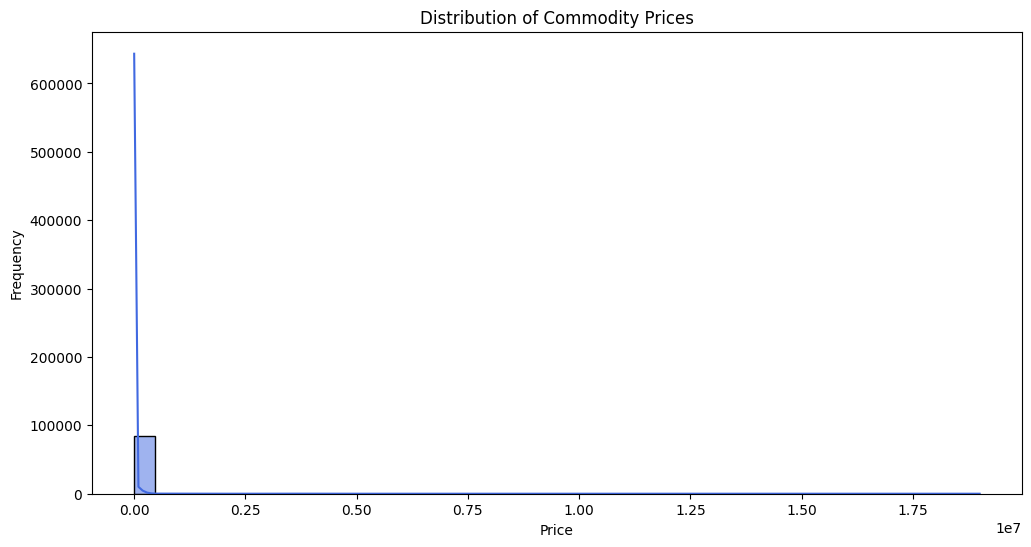

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['price'],
    bins=40,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Commodity Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

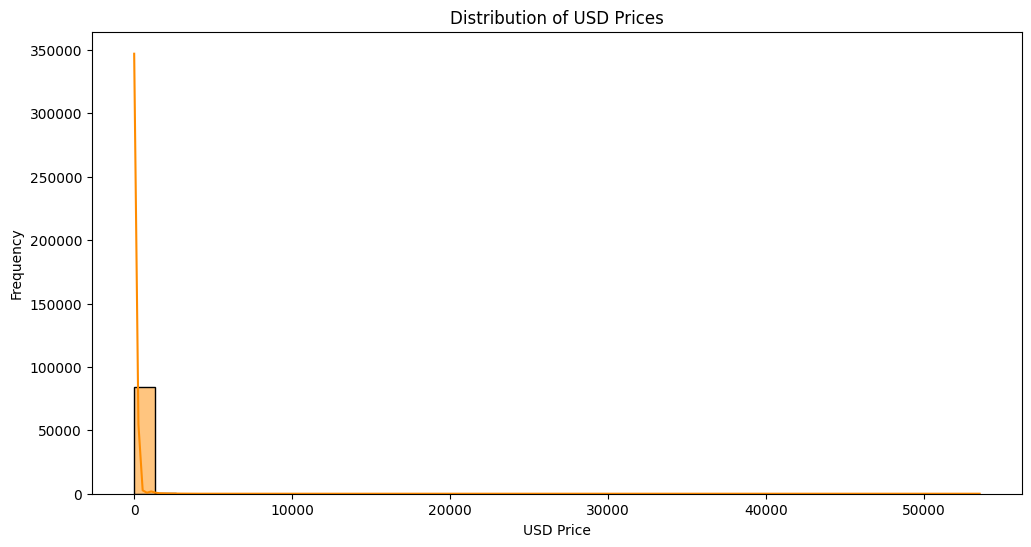

In [18]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['usdprice'],
    bins=40,
    kde=True,
    color='darkorange'
)

plt.title("Distribution of USD Prices")
plt.xlabel("USD Price")
plt.ylabel("Frequency")

plt.show()

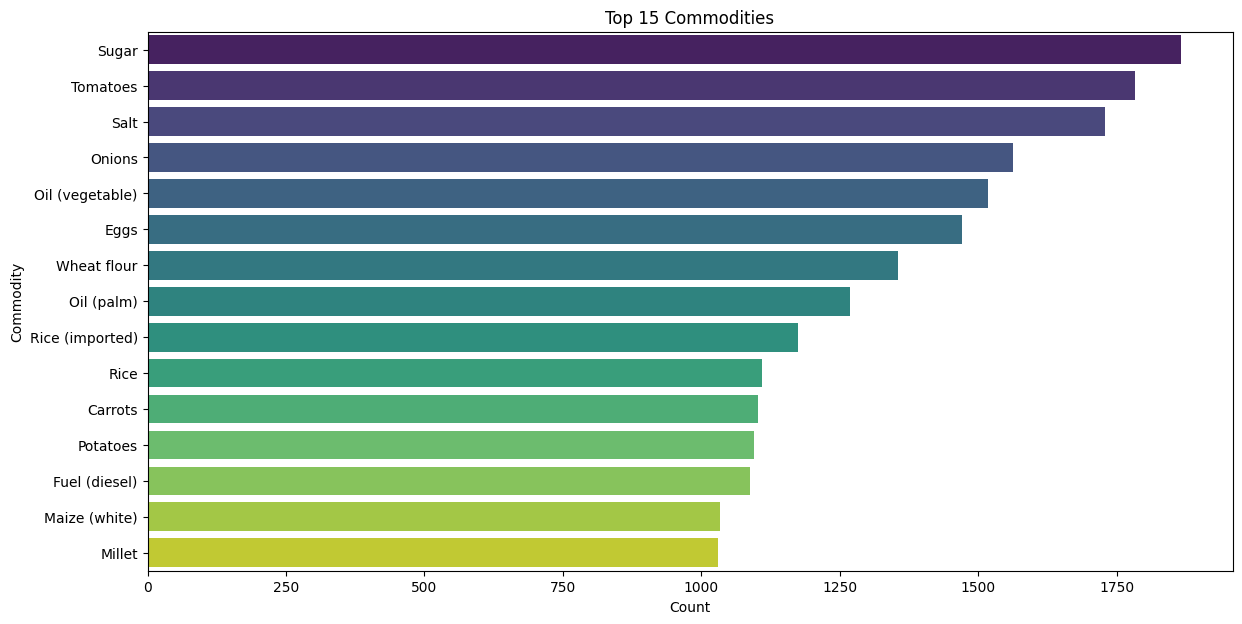

In [19]:
top_commodities = df['commodity'].value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_commodities.values,
    y=top_commodities.index,
    palette='viridis'
)

plt.title("Top 15 Commodities")
plt.xlabel("Count")
plt.ylabel("Commodity")

plt.show()

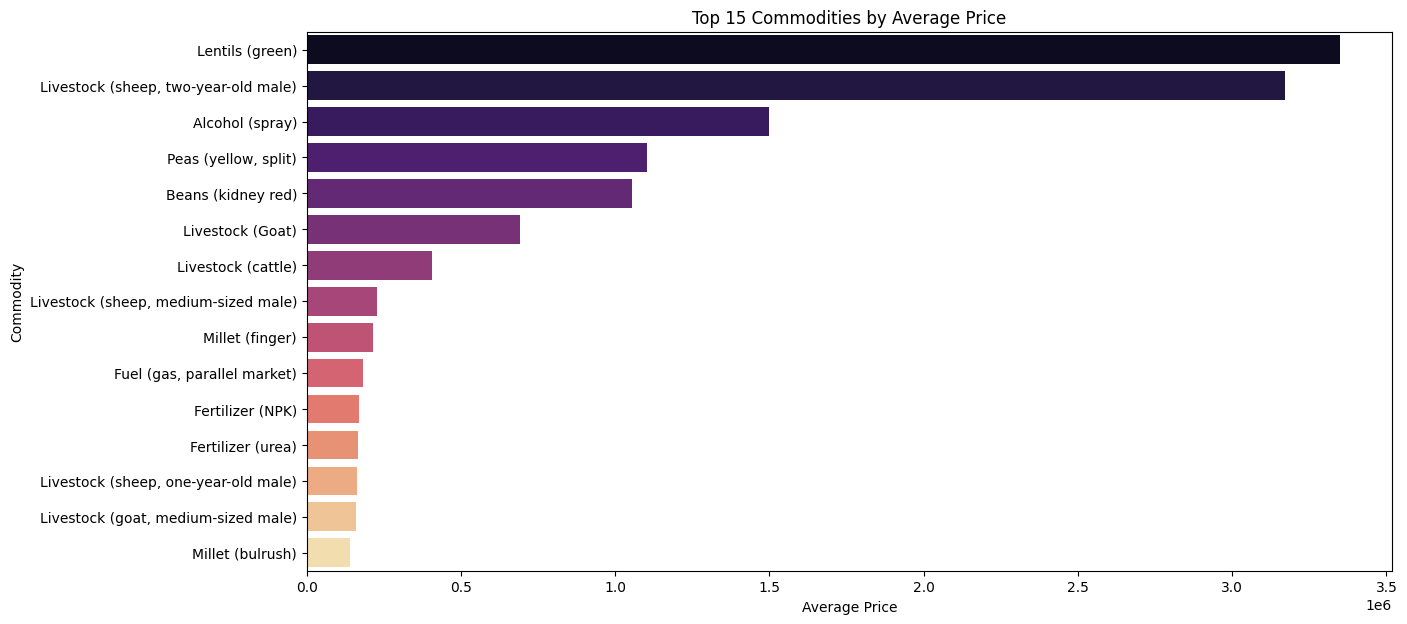

In [20]:
commodity_price = (
    df.groupby('commodity')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=commodity_price.values,
    y=commodity_price.index,
    palette='magma'
)

plt.title("Top 15 Commodities by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Commodity")

plt.show()

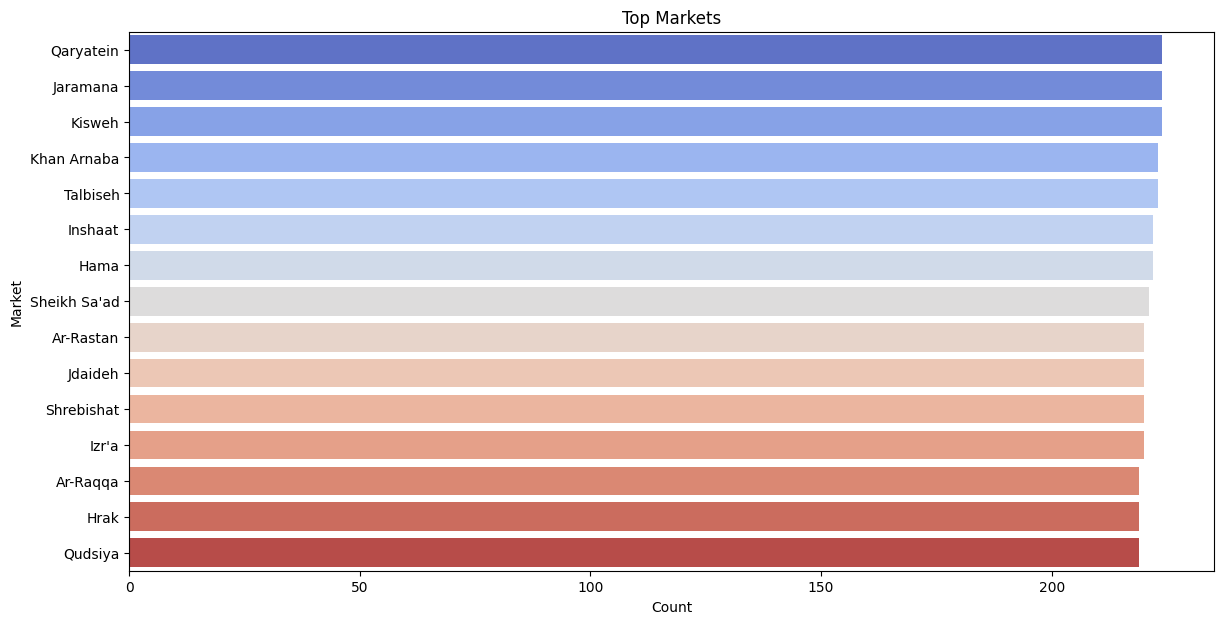

In [21]:
top_markets = df['market'].value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_markets.values,
    y=top_markets.index,
    palette='coolwarm'
)

plt.title("Top Markets")
plt.xlabel("Count")
plt.ylabel("Market")

plt.show()

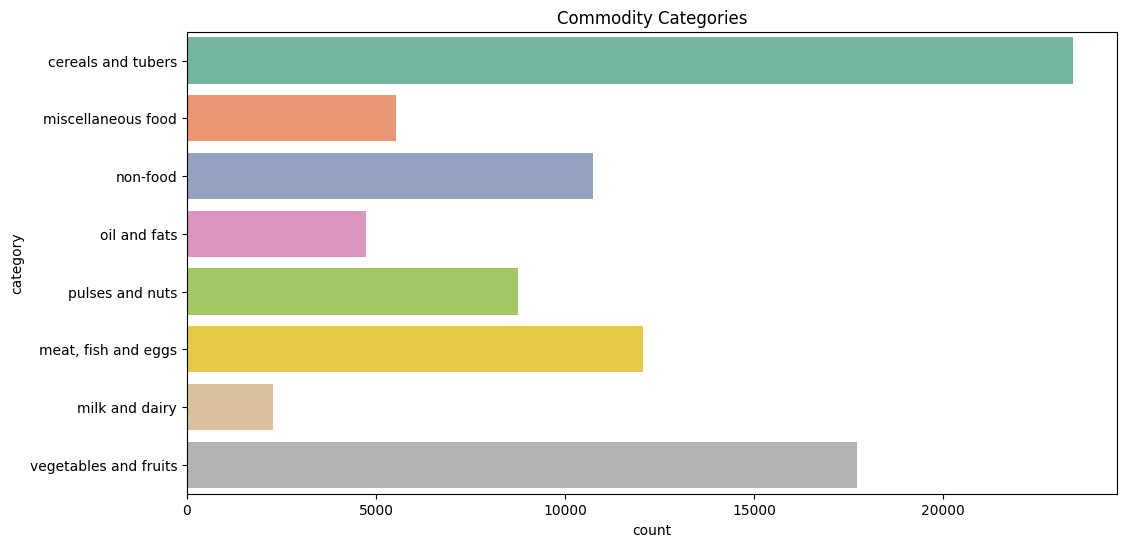

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    data=df,
    palette='Set2'
)

plt.title("Commodity Categories")
plt.show()

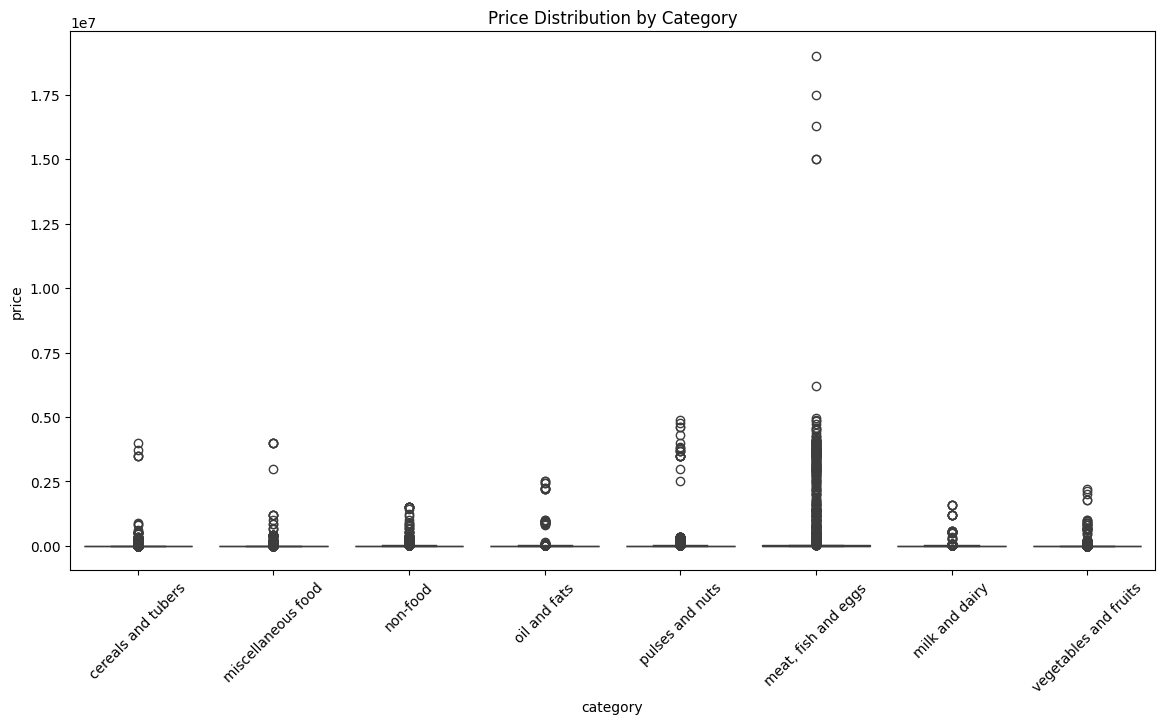

In [23]:
plt.figure(figsize=(14,7))

sns.boxplot(
    x='category',
    y='price',
    data=df,
    palette='tab10'
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Category")

plt.show()

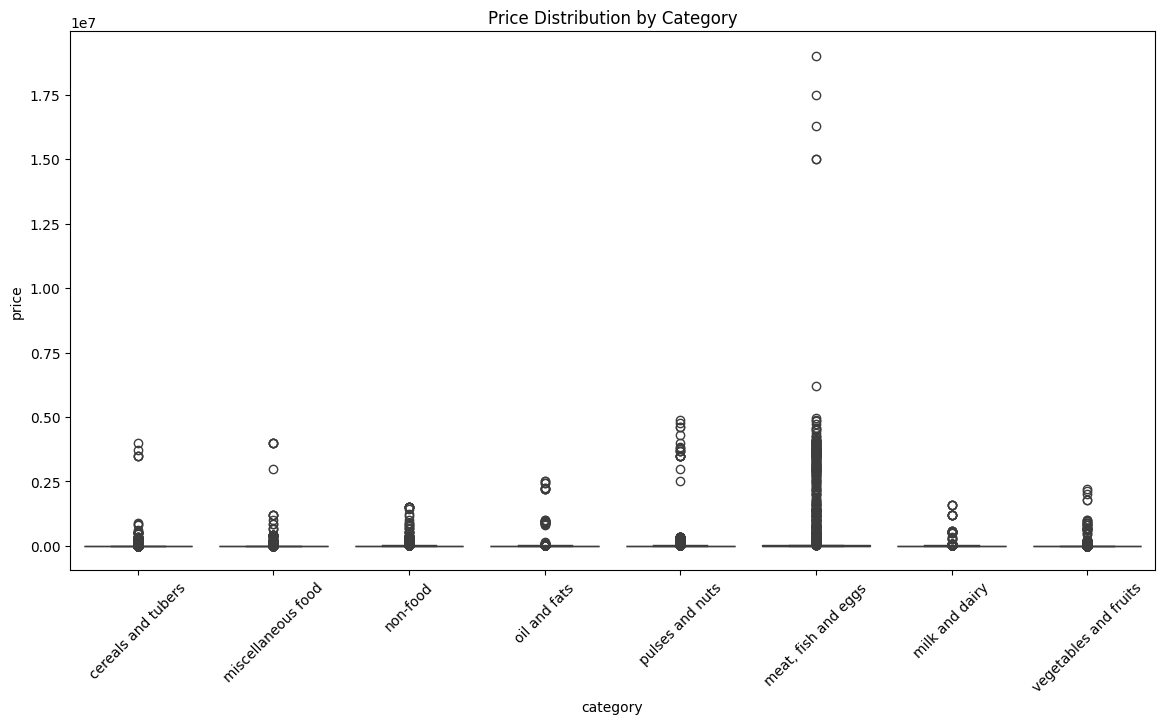

In [24]:
plt.figure(figsize=(14,7))

sns.boxplot(
    x='category',
    y='price',
    data=df,
    palette='tab10'
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Category")

plt.show()

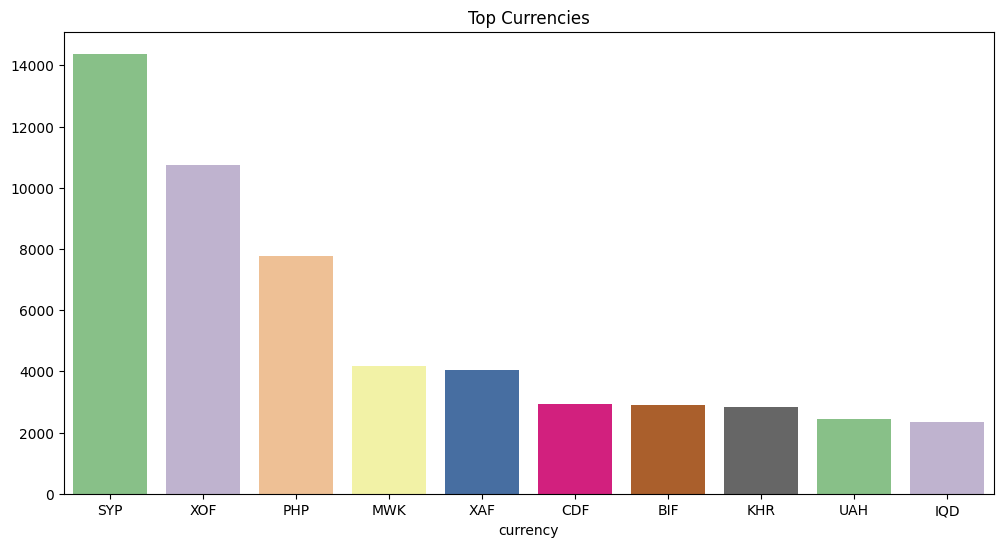

In [25]:
currency_counts = df['currency'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=currency_counts.index,
    y=currency_counts.values,
    palette='Accent'
)

plt.title("Top Currencies")

plt.show()

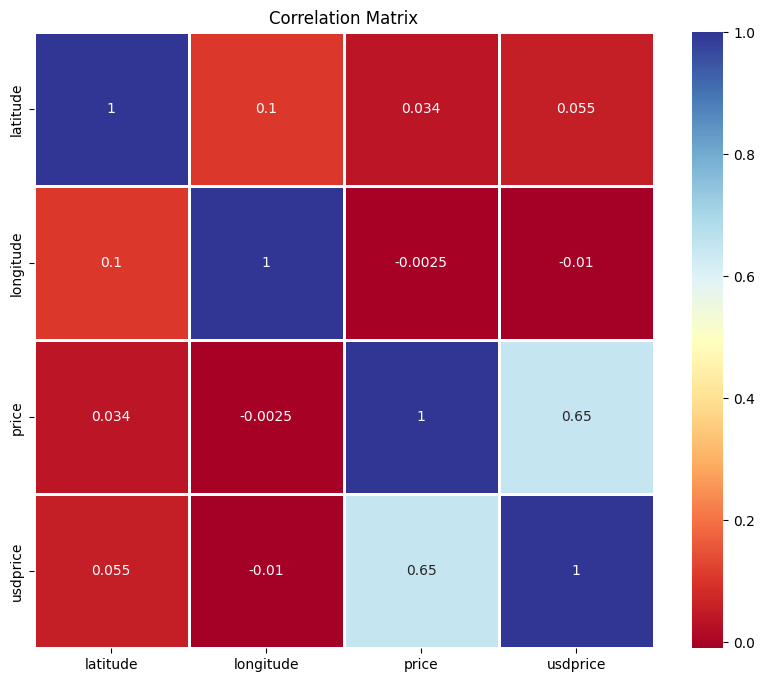

In [26]:
numeric_cols = [
    'latitude',
    'longitude',
    'price',
    'usdprice'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',
    linewidths=1
)

plt.title("Correlation Matrix")

plt.show()

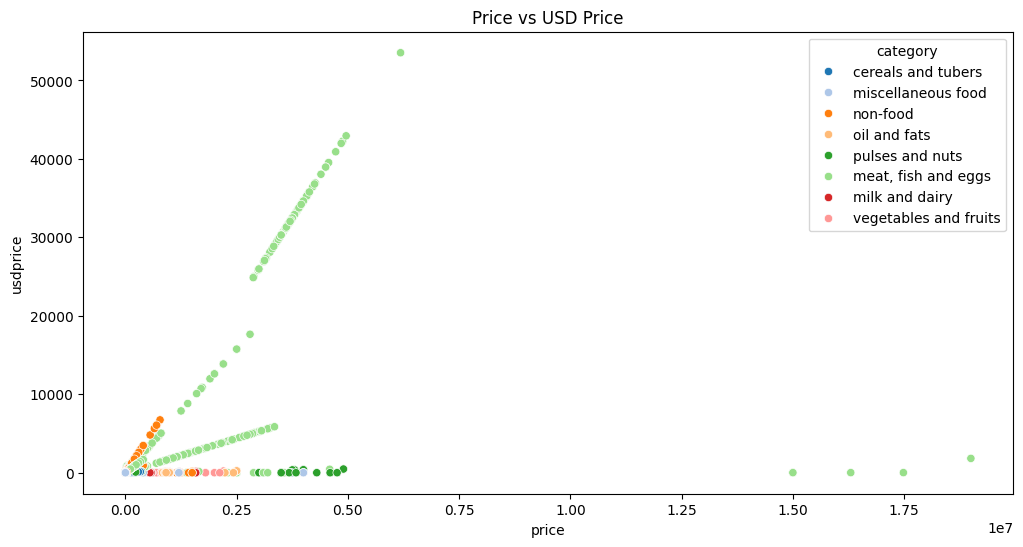

In [27]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='price',
    y='usdprice',
    data=df,
    hue='category',
    palette='tab20'
)

plt.title("Price vs USD Price")

plt.show()

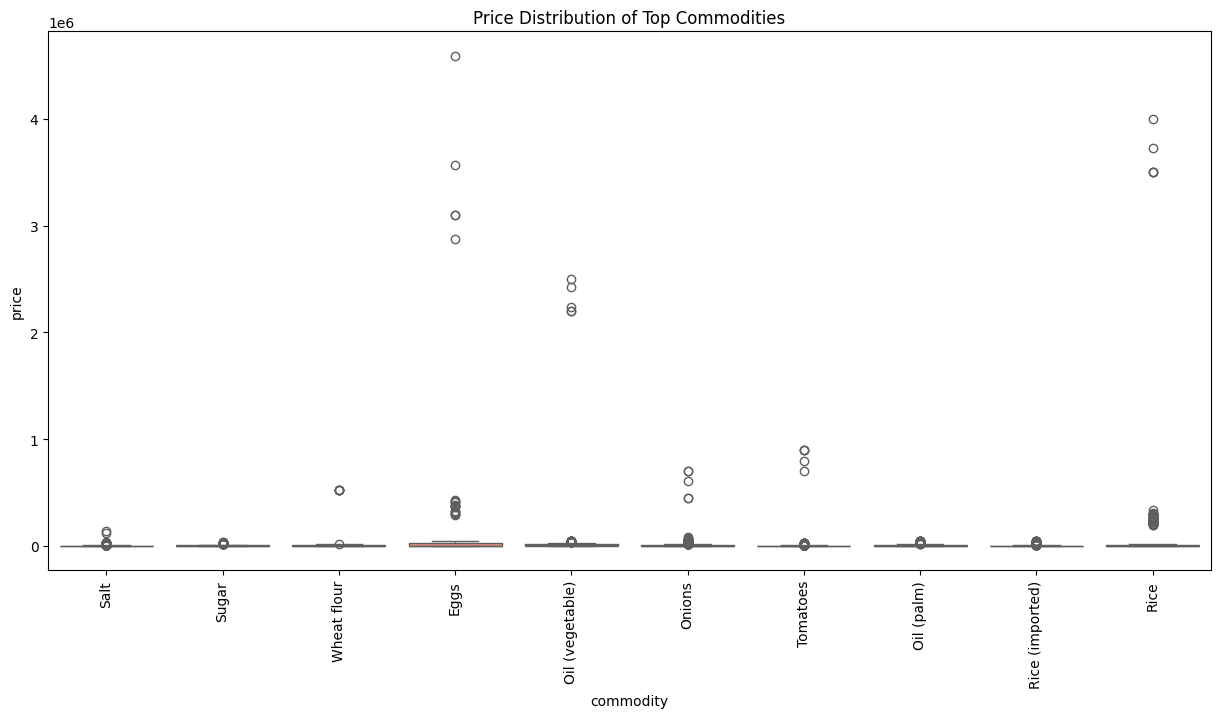

In [28]:
top10 = df['commodity'].value_counts().head(10).index

temp = df[df['commodity'].isin(top10)]

plt.figure(figsize=(15,7))

sns.boxplot(
    x='commodity',
    y='price',
    data=temp,
    palette='Set3'
)

plt.xticks(rotation=90)

plt.title("Price Distribution of Top Commodities")

plt.show()

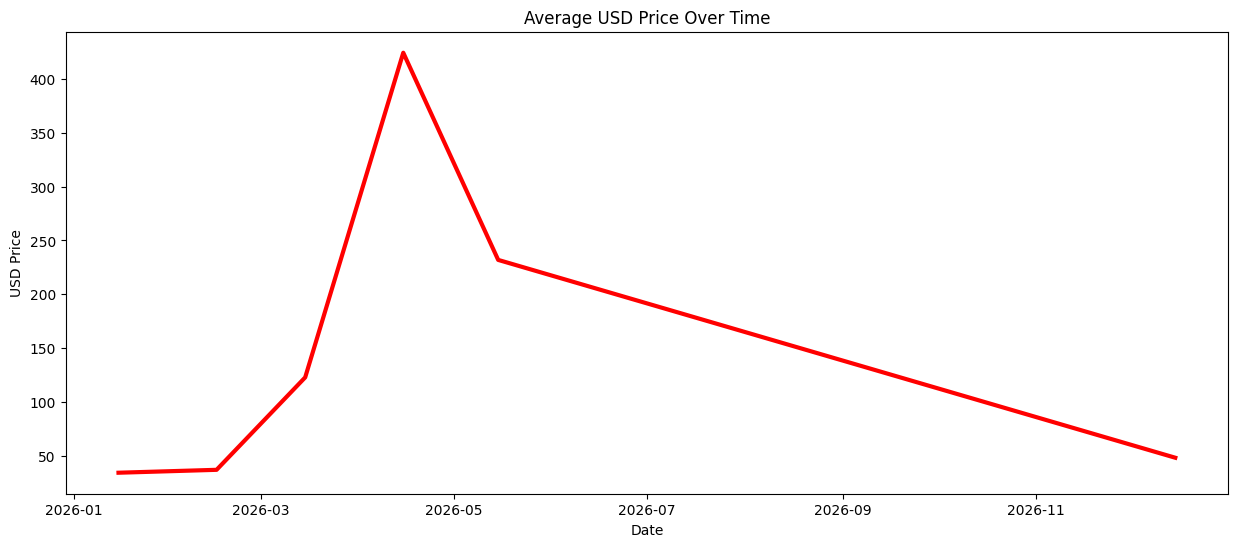

In [29]:
df['date'] = pd.to_datetime(df['date'])

monthly_price = (
    df.groupby('date')['usdprice']
    .mean()
    .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_price['date'],
    monthly_price['usdprice'],
    color='red',
    linewidth=3
)

plt.title("Average USD Price Over Time")
plt.xlabel("Date")
plt.ylabel("USD Price")

plt.show()

In [30]:
fig = px.box(
    df,
    x='category',
    y='usdprice',
    color='category',
    title='USD Price Distribution by Category'
)

fig.show()

In [31]:
fig = px.treemap(
    df,
    path=['category','commodity'],
    values='usdprice',
    color='usdprice',
    color_continuous_scale='RdBu'
)

fig.show()

In [32]:
fig = px.sunburst(
    df,
    path=['category','commodity'],
    values='usdprice',
    color='usdprice'
)

fig.show()

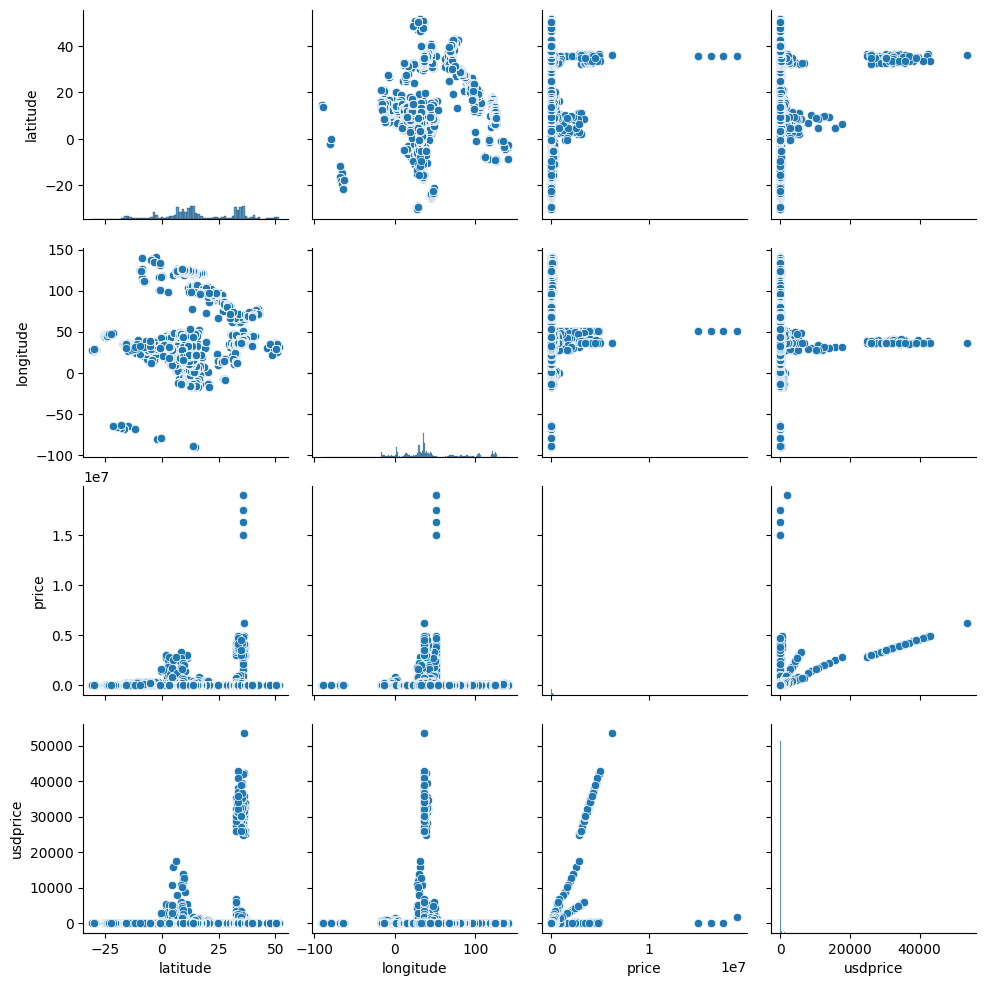

In [33]:
sns.pairplot(
    df[['latitude','longitude','price','usdprice']],
    palette='husl'
)

plt.show()

## Feature engineering

target
0    42646
1    42643
Name: count, dtype: int64

Categorical Columns
['countryiso3', 'admin1', 'admin2', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency']

Numerical Columns
['market_id', 'latitude', 'longitude', 'commodity_id']

Train Shape: (68231, 19)
Test Shape : (17058, 19)


Logistic Regression
Accuracy : 0.9544
AUC Score: 0.9898

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8529
           1       0.96      0.95      0.95      8529

    accuracy                           0.95     17058
   macro avg       0.95      0.95      0.95     17058
weighted avg       0.95      0.95      0.95     17058



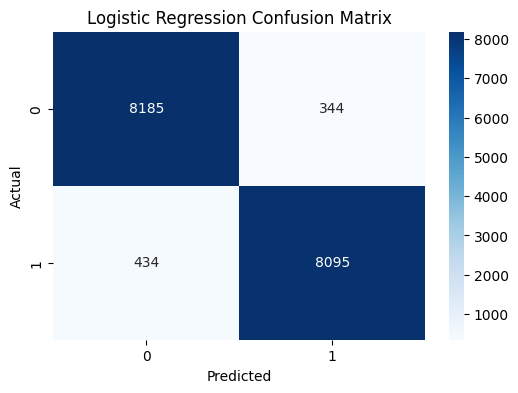



Random Forest
Accuracy : 0.9832
AUC Score: 0.9981

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8529
           1       0.98      0.98      0.98      8529

    accuracy                           0.98     17058
   macro avg       0.98      0.98      0.98     17058
weighted avg       0.98      0.98      0.98     17058



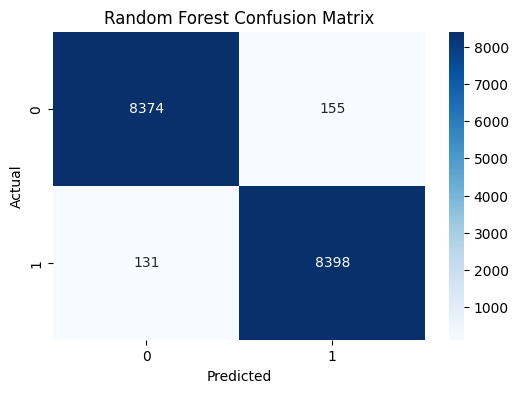



Gradient Boosting
Accuracy : 0.9365
AUC Score: 0.9831

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      8529
           1       0.94      0.93      0.94      8529

    accuracy                           0.94     17058
   macro avg       0.94      0.94      0.94     17058
weighted avg       0.94      0.94      0.94     17058



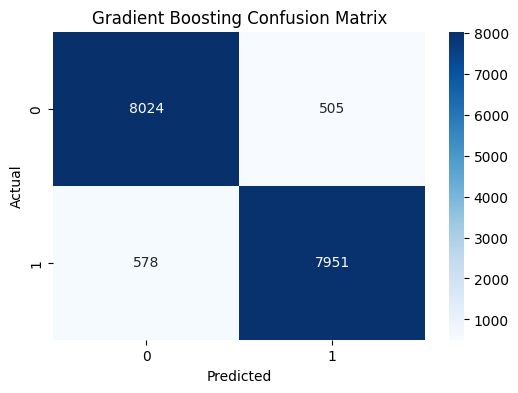


Model Comparison
                 Model  Accuracy       AUC
1        Random Forest  0.983234  0.998096
0  Logistic Regression  0.954391  0.989775
2    Gradient Boosting  0.936511  0.983056


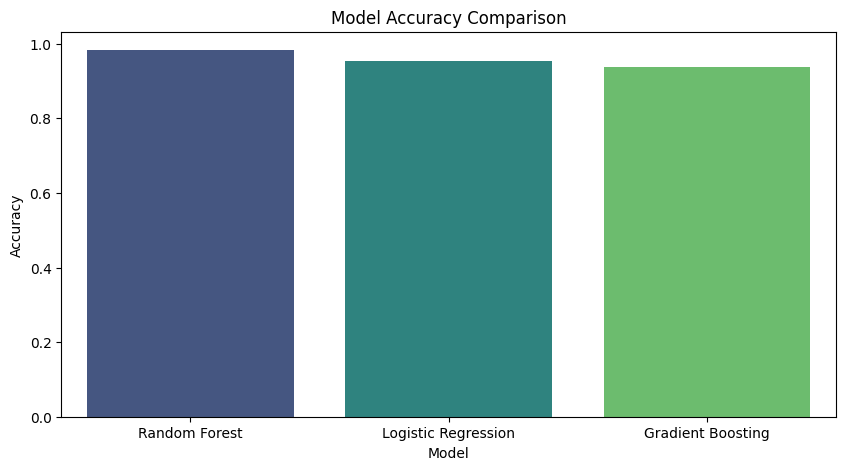

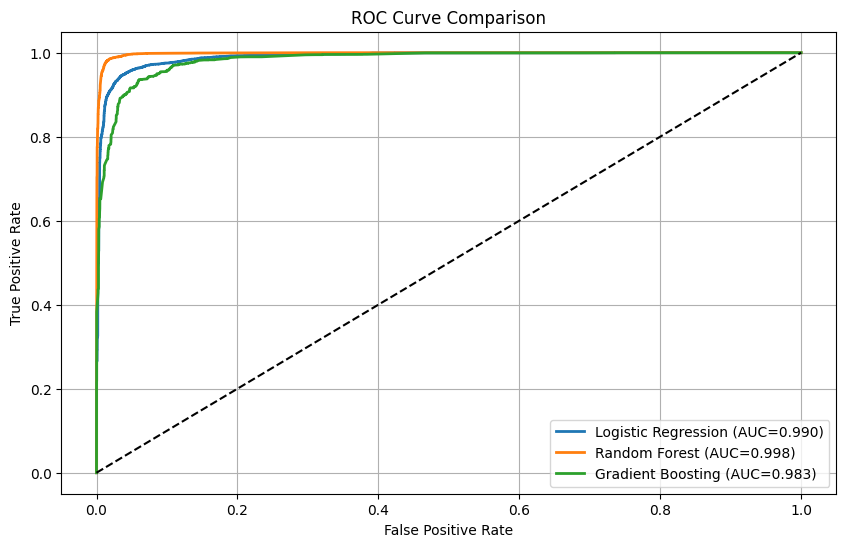


Best Model
Model       Random Forest
Accuracy         0.983234
AUC              0.998096
Name: 1, dtype: object

Dataset Shape: (85289, 22)

Target Distribution
target
0    42646
1    42643
Name: count, dtype: int64


In [34]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


data = df.copy()



data['date'] = pd.to_datetime(data['date'])

data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['dayofweek'] = data['date'].dt.dayofweek
data['quarter'] = data['date'].dt.quarter

# Remove original date
data.drop('date', axis=1, inplace=True)

# High Price vs Low Price

median_price = data['price'].median()

data['target'] = np.where(
    data['price'] > median_price,
    1,
    0
)

print(data['target'].value_counts())


X = data.drop(
    columns=[
        'target',
        'price',
        'usdprice'
    ]
)

y = data['target']


cat_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\nCategorical Columns")
print(cat_cols)

print("\nNumerical Columns")
print(num_cols)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)



numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            num_cols
        ),
        (
            'cat',
            categorical_transformer,
            cat_cols
        )
    ]
)


models = {

    'Logistic Regression':
    LogisticRegression(
        max_iter=1000
    ),

    'Random Forest':
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    'Gradient Boosting':
    GradientBoostingClassifier(
        random_state=42
    )

}


results = []

roc_data = {}

for name, model in models.items():

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    pipeline = Pipeline(
        steps=[
            (
                'preprocessor',
                preprocessor
            ),
            (
                'classifier',
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Predict
    y_pred = pipeline.predict(
        X_test
    )

    # Probabilities
    y_prob = pipeline.predict_proba(
        X_test
    )[:, 1]

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # AUC
    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"AUC Score: {auc_score:.4f}"
    )

    # Classification Report
    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f'{name} Confusion Matrix'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # Store Results
    results.append(
        [
            name,
            accuracy,
            auc_score
        ]
    )

    # ROC Data
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_data[name] = (
        fpr,
        tpr,
        auc_score
    )


results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'AUC'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\nModel Comparison")
print(results_df)


plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    hue='Model',
    legend=False,
    palette='viridis'
)

plt.title(
    'Model Accuracy Comparison'
)

plt.show()


plt.figure(figsize=(10,6))

for model_name, values in roc_data.items():

    fpr, tpr, auc_score = values

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC={auc_score:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend()

plt.grid(True)

plt.show()


best_model = results_df.iloc[0]

print("\nBest Model")
print(best_model)


print("\nDataset Shape:", data.shape)

print("\nTarget Distribution")

print(
    data['target']
    .value_counts()
)